<a href="https://colab.research.google.com/github/SKM1919/liftlens/blob/main/notebooks/02_uplift_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LiftLens: Uplift Models (Medium tier)
Goal: predict the email's effect on each individual customer, not just on average.

In [1]:
!pip install scikit-uplift xgboost -q

import pandas as pd
import numpy as np
from sklift.datasets import fetch_hillstrom
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Load data
bunch = fetch_hillstrom(target_col='all')
df = pd.concat([bunch.data, bunch.target, bunch.treatment], axis=1)

# Keep only Mens E-Mail vs No E-Mail, and make a 0/1 treatment flag
df = df[df['segment'].isin(['Mens E-Mail', 'No E-Mail'])].copy()
df['treatment'] = (df['segment'] == 'Mens E-Mail').astype(int)

# Features: customer info known BEFORE the email was sent
features = ['recency', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']
X = pd.get_dummies(df[features], columns=['zip_code', 'channel'], dtype=int)
y = df['visit']
t = df['treatment']

# 70% train, 30% test, keeping treatment/visit balance the same in both
X_train, X_test, y_train, y_test, t_train, t_test = train_test_split(
    X, y, t, test_size=0.3, random_state=42,
    stratify=t.astype(str) + y.astype(str)
)

print("Train:", X_train.shape, " Test:", X_test.shape)
X_train.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.5 MB/s eta 0:00:00


Hillstrom dataset:   0%|          | 0.00/443k [00:00<?, ?iB/s]

Train: (29829, 11)  Test: (12784, 11)


,recency,history,mens,womens,newbie,zip_code_Rural,zip_code_Surburban,zip_code_Urban,channel_Multichannel,channel_Phone,channel_Web
37645,2,219.05,0,1,1,0,0,1,1,0,0
56937,6,206.61,0,1,0,0,1,0,0,0,1
19588,2,600.39,0,1,1,0,0,1,0,1,0
14247,2,387.24,1,0,0,0,0,1,1,0,0
48850,4,29.99,1,0,1,0,1,0,0,0,1


In [2]:
params = dict(n_estimators=200, max_depth=3, learning_rate=0.05,
              random_state=42, eval_metric='logloss')

# Model A: learns from emailed customers only
model_treated = XGBClassifier(**params)
model_treated.fit(X_train[t_train == 1], y_train[t_train == 1])

# Model B: learns from non-emailed customers only
model_control = XGBClassifier(**params)
model_control.fit(X_train[t_train == 0], y_train[t_train == 0])

# For every test customer, ask both models and subtract
p_if_emailed = model_treated.predict_proba(X_test)[:, 1]
p_if_not = model_control.predict_proba(X_test)[:, 1]
uplift_t = p_if_emailed - p_if_not

print("Done. First 5 predicted uplifts:", np.round(uplift_t[:5], 3))

Done. First 5 predicted uplifts: [0.116 0.052 0.064 0.081 0.014]


In [3]:
actual_lift = y_test[t_test == 1].mean() - y_test[t_test == 0].mean()
print(f"Actual lift on test set:   {actual_lift * 100:.2f} pp")
print(f"Average predicted uplift:  {uplift_t.mean() * 100:.2f} pp")
print(f"Share with negative uplift: {(uplift_t < 0).mean() * 100:.1f}%")

pd.Series(uplift_t * 100).describe().round(2)


Actual lift on test set:   7.65 pp
Average predicted uplift:  7.62 pp
Share with negative uplift: 1.7%


,0
count,12784.00
mean,7.62
std,3.88
min,-14.48
25%,5.34
50%,7.11
75%,9.55
max,26.85


## S-learner and model comparison

In [4]:
# Add the treatment flag as a feature
X_train_s = X_train.copy()
X_train_s['treatment'] = t_train.values

model_s = XGBClassifier(**params)
model_s.fit(X_train_s, y_train)

# Ask the same model two "what if" questions
X_test_emailed = X_test.copy()
X_test_emailed['treatment'] = 1

X_test_not = X_test.copy()
X_test_not['treatment'] = 0

uplift_s = (model_s.predict_proba(X_test_emailed)[:, 1]
            - model_s.predict_proba(X_test_not)[:, 1])

print(f"Average predicted uplift (S): {uplift_s.mean() * 100:.2f} pp")
print(f"Share with negative uplift (S): {(uplift_s < 0).mean() * 100:.1f}%")

Average predicted uplift (S): 7.43 pp
Share with negative uplift (S): 0.1%


In [5]:
comparison = pd.DataFrame({
    'T-learner': uplift_t * 100,
    'S-learner': uplift_s * 100
})

print(comparison.describe().round(2))
print("\nCorrelation between the two:", round(comparison.corr().iloc[0, 1], 2))

       T-learner  S-learner
count   12784.00   12784.00
mean        7.62       7.43
std         3.88       2.79
min       -14.48      -2.78
25%         5.34       5.65
50%         7.11       7.16
75%         9.55       8.41
max        26.85      22.87

Correlation between the two: 0.66


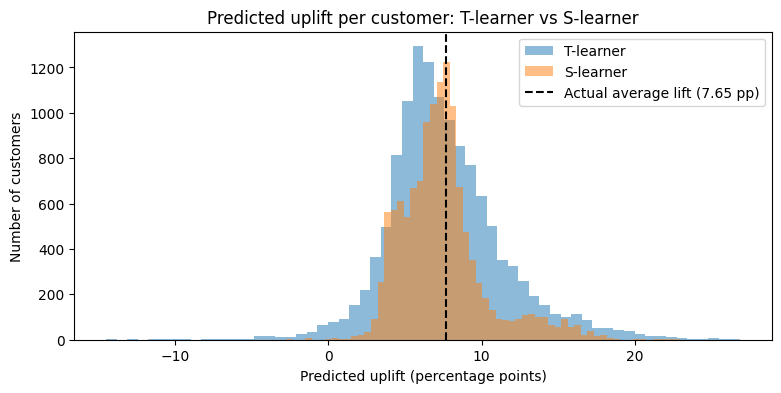

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4))
plt.hist(comparison['T-learner'], bins=60, alpha=0.5, label='T-learner')
plt.hist(comparison['S-learner'], bins=60, alpha=0.5, label='S-learner')
plt.axvline(7.65, color='black', linestyle='--', label='Actual average lift (7.65 pp)')
plt.xlabel('Predicted uplift (percentage points)')
plt.ylabel('Number of customers')
plt.title('Predicted uplift per customer: T-learner vs S-learner')
plt.legend()
plt.show()

## Evaluating uplift models (deciles, Qini, AUUC)

In [7]:
def uplift_by_decile(uplift, y, t, n_bins=10):
    d = pd.DataFrame({'uplift': uplift, 'y': y.values, 't': t.values})
    # decile 1 = customers with the HIGHEST predicted uplift
    d['decile'] = pd.qcut(d['uplift'].rank(method='first', ascending=False),
                          n_bins, labels=range(1, n_bins + 1))
    rows = []
    for dec, g in d.groupby('decile', observed=True):
        actual = g.loc[g.t == 1, 'y'].mean() - g.loc[g.t == 0, 'y'].mean()
        rows.append({'decile': dec,
                     'predicted_pp': g['uplift'].mean() * 100,
                     'actual_pp': actual * 100})
    return pd.DataFrame(rows).round(2)

deciles = uplift_by_decile(uplift_t, y_test, t_test).merge(
    uplift_by_decile(uplift_s, y_test, t_test),
    on='decile', suffixes=('_T', '_S'))
deciles


,decile,predicted_pp_T,actual_pp_T,predicted_pp_S,actual_pp_S
0,1,15.51,10.32,13.79,14.26
1,2,11.20,8.10,9.55,4.49
2,3,9.56,7.03,8.42,7.04
3,4,8.46,9.84,7.86,5.45
4,5,7.53,6.24,7.41,7.26
5,6,6.73,5.28,6.91,8.42
6,7,6.04,5.14,6.36,7.20
7,8,5.31,7.39,5.66,6.10
8,9,4.35,6.42,4.73,10.33
9,10,1.55,11.08,3.62,6.29


In [8]:
from sklift.metrics import qini_auc_score, uplift_auc_score, uplift_at_k

scores = pd.DataFrame({
    'model': ['T-learner', 'S-learner'],
    'Qini AUC': [qini_auc_score(y_test, u, t_test) for u in (uplift_t, uplift_s)],
    'AUUC': [uplift_auc_score(y_test, u, t_test) for u in (uplift_t, uplift_s)],
    'uplift@30% (pp)': [uplift_at_k(y_test, u, t_test, strategy='overall', k=0.3) * 100
                        for u in (uplift_t, uplift_s)],
})
scores.round(4)


,model,Qini AUC,AUUC,uplift@30% (pp)
0,T-learner,0.0055,0.0031,8.4070
1,S-learner,0.0097,0.0052,8.3434


### Findings
- **S-learner ranks customers better** (Qini AUC 0.0097 vs 0.0055 for T-learner). Its top decile showed a real lift of 14.3 pp, nearly double the 7.65 pp average.
- **But the overall gain is modest:** targeting the top 30% gives ~8.4 pp lift vs 7.65 pp for random emailing (~10% better).
- **Deciles are noisy:** each holds ~640 customers per arm, giving a margin of error of about ±4 pp, so most of the zig-zag is noise, as the MDE analysis predicted.
- **Business conclusion:** the Mens email helps almost everyone by a similar amount, so with near-zero email cost, "email everyone" is hard to beat. Uplift targeting adds most value when effects vary widely or contact is costly, which the Hard tier tests with Criteo and a profit curve.

## Targeting policy and profit

In [9]:
treated = df[df['treatment'] == 1]
control_grp = df[df['treatment'] == 0]

incr_spend = treated['spend'].mean() - control_grp['spend'].mean()
incr_visit = treated['visit'].mean() - control_grp['visit'].mean()
revenue_per_incr_visit = incr_spend / incr_visit

MARGIN = 0.30   # assumption: 30% gross margin
VALUE_PER_VISIT = revenue_per_incr_visit * MARGIN

print(f"Extra revenue per extra visit: ${revenue_per_incr_visit:.2f}")
print(f"Profit per extra visit (at {MARGIN:.0%} margin): ${VALUE_PER_VISIT:.2f}")

Extra revenue per extra visit: $10.05
Profit per extra visit (at 30% margin): $3.02


In [10]:
COSTS = {
    'Email ($0.05)': 0.05,
    'SMS ($0.20)': 0.20,
    'Direct mail ($0.40)': 0.40,
}

# Sort test customers by S-learner predicted uplift, best first
d = (pd.DataFrame({'uplift': uplift_s, 'y': y_test.values, 't': t_test.values})
       .sort_values('uplift', ascending=False)
       .reset_index(drop=True))
n_total = len(d)

rows = []
for frac in np.arange(0.05, 1.0001, 0.05):
    top = d.iloc[:int(round(frac * n_total))]
    # REAL lift among the customers we'd target (from the experiment)
    lift = top.loc[top.t == 1, 'y'].mean() - top.loc[top.t == 0, 'y'].mean()
    extra_visits = lift * len(top)
    for channel, cost in COSTS.items():
        profit = extra_visits * VALUE_PER_VISIT - cost * len(top)
        rows.append({
            'channel': channel,
            'target_%': round(frac * 100),
            'lift_pp': round(lift * 100, 2),
            'profit_per_10k': round(profit / n_total * 10_000),
        })

policy = pd.DataFrame(rows)
policy.head()

,channel,target_%,lift_pp,profit_per_10k
0,Email ($0.05),5,20.17,279
1,SMS ($0.20),5,20.17,204
2,Direct mail ($0.40),5,20.17,104
3,Email ($0.05),10,14.23,379
4,SMS ($0.20),10,14.23,229


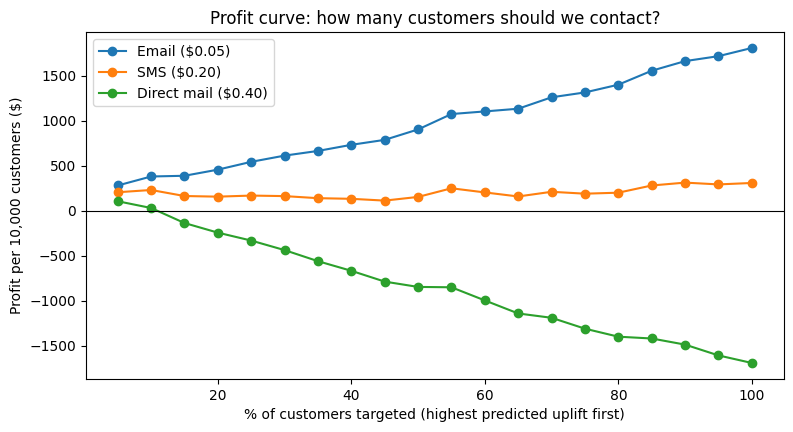

In [11]:
plt.figure(figsize=(9, 4.5))
for channel in COSTS:
    sub = policy[policy['channel'] == channel]
    plt.plot(sub['target_%'], sub['profit_per_10k'], marker='o', label=channel)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('% of customers targeted (highest predicted uplift first)')
plt.ylabel('Profit per 10,000 customers ($)')
plt.title('Profit curve: how many customers should we contact?')
plt.legend()
plt.show()

In [12]:
summary = []
for channel in COSTS:
    sub = policy[policy['channel'] == channel]
    best = sub.loc[sub['profit_per_10k'].idxmax()]
    everyone = sub[sub['target_%'] == 100].iloc[0]
    summary.append({
        'channel': channel,
        'best_target_%': best['target_%'],
        'best_profit': best['profit_per_10k'],
        'email_everyone_profit': everyone['profit_per_10k'],
        'gain_vs_everyone': best['profit_per_10k'] - everyone['profit_per_10k'],
    })
pd.DataFrame(summary)

,channel,best_target_%,best_profit,email_everyone_profit,gain_vs_everyone
0,Email ($0.05),100,1807,1807,0
1,SMS ($0.20),90,311,307,4
2,Direct mail ($0.40),5,104,-1693,1797
